In [35]:
import numpy as np
import os
import seaborn as sb
import globals as gl
import pingouin as pg
import PcmPy as pcm
from pcm_models import find_model
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import pickle
import pandas as pd
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
from sklearn.preprocessing import MinMaxScaler
import nibabel as nb
import nitools as nt
plt.style.use('default')

In [36]:
experiment = 'smp2'
glm = 12
H = 'L'
epoch = 'plan'
rois = gl.rois['ROI']

SMA: tval=3.5010671094999073, pval=0.0019530226706477509
PMd: tval=4.598273847949548, pval=0.00024963097770992716
PMv: tval=5.3808301566361045, pval=6.25938114432965e-05
M1: tval=4.899815837755327, pval=0.00014509603765901948
S1: tval=7.019441292795594, pval=4.537072556005718e-06
SPLa: tval=4.418617091916282, pval=0.000346742520476346
SPLp: tval=6.069299768949967, pval=1.986392417741581e-05


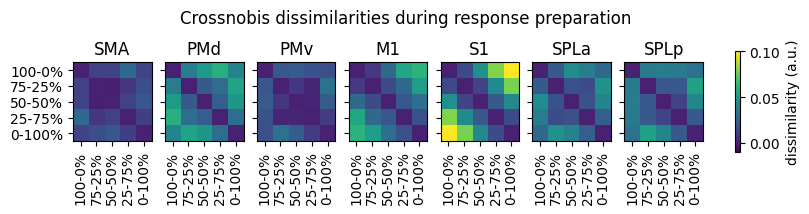

In [37]:
from vis import plot_dissimilarities

vmin, vmax = -.01, .1

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
tr_null_plan, tr_pot_plan = [], []
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    tr_null_plan.append(np.trace(G, axis1=1, axis2=2))
    D = pcm.G_to_dist(G)
    fig, axs = plot_dissimilarities(fig, axs, r, D, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=False, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response preparation')

plt.show()

                                T  dof alternative     p-val         CI95%  \
roi  component                                                               
M1   expectation T-test  2.446785   13     greater  0.014695   [5.97, inf]   
     uncertainty T-test  1.420972   13     greater  0.089433  [-0.47, inf]   
PMd  expectation T-test  3.697104   13     greater  0.001342   [5.15, inf]   
     uncertainty T-test  2.108148   13     greater  0.027496   [4.07, inf]   
PMv  expectation T-test  1.618486   13     greater  0.064776  [-0.12, inf]   
     uncertainty T-test  2.124096   13     greater  0.026710   [0.56, inf]   
S1   expectation T-test  3.397400   13     greater  0.002383  [34.48, inf]   
     uncertainty T-test  2.164677   13     greater  0.024804   [0.56, inf]   
SMA  expectation T-test  1.081856   13     greater  0.149488  [-0.58, inf]   
     uncertainty T-test  1.570233   13     greater  0.070186  [-0.31, inf]   
SPLa expectation T-test  3.034924   13     greater  0.004787   [

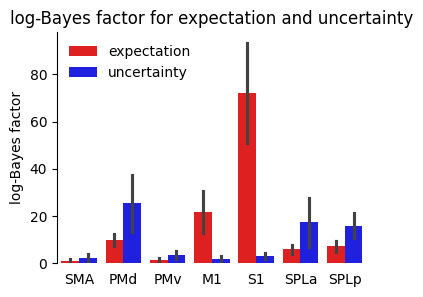

In [41]:
df = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'component_model.tsv'), sep='\t')
df = df[(df['epoch']=='plan') & (df['Hem']==H)]
fig, ax = plt.subplots(figsize=(4, 3))
sb.barplot(ax=ax, data=df, x='roi', y='BF', hue='component', palette=['red', 'blue'], errorbar='se')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('log-Bayes factor')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor for expectation and uncertainty')
results = df.groupby(['roi', 'component']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
print(results)
plt.show()

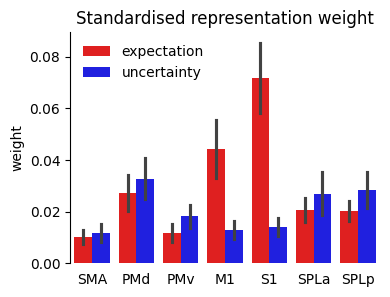

In [33]:
fig, ax = plt.subplots(figsize=(4, 3))
sb.barplot(ax=ax, data=df, x='roi', y='weight', hue='component', palette=['red', 'blue'], errorbar='se')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation weight')
plt.show()

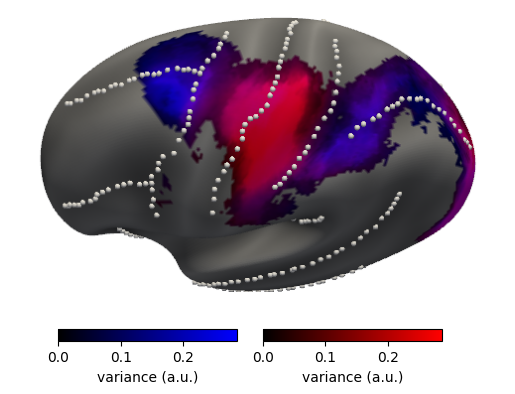

In [7]:
from vis import plot_surf

mclip = .2
threshold = .05 / mclip
scaler = MinMaxScaler()

gifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'searchlight.var_expl.plan.{H}.func.gii'))
data = nt.get_gifti_data_matrix(gifti)
raw_max = np.nanmax(data)
data = data / raw_max#scaler.fit_transform(data)
raw_min = 0 #scaler.inverse_transform([[threshold * mclip, threshold * mclip]])[0,0]
data = np.clip(data / mclip, 0, 1)

sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
sulc = sulc[:len(data)]
sulc_norm = MinMaxScaler((0.3, 0.7)).fit_transform(sulc.reshape(-1, 1)).flatten()

rgba = np.zeros((len(sulc_norm), 4))
rgba[:, 0] = sulc_norm  # red = grey
rgba[:, 1] = sulc_norm  # green = grey
rgba[:, 2] = sulc_norm  # blue = grey
rgba[:, 3] = 1.0        # opaque background

overlay_mask = (data[:, 0] >= threshold) | (data[:, 1] >= threshold)

rgba[overlay_mask, 0] = data[overlay_mask, 0]  # red
rgba[overlay_mask, 1] = 0                    # green stays off for 2-color blend
rgba[overlay_mask, 2] = data[overlay_mask, 1]  # blue
rgba[overlay_mask, 3] = 1.0                     # alpha: opaque overlay
rgba[~overlay_mask, 3] = 1.0                    # still show grey background

fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, rgba, H, cmap=None, vmin=None, vmax=None, overlay='rgb')

blue_half = LinearSegmentedColormap.from_list("blue_half", ["black", "blue"])
neg_norm = Normalize(vmin=raw_min, vmax=raw_max)
sm_neg = ScalarMappable(norm=neg_norm, cmap=blue_half)

red_half = LinearSegmentedColormap.from_list("red_half", ["black", "red"])
pos_norm = Normalize(vmin=raw_min, vmax=raw_max)
sm_pos = ScalarMappable(norm=pos_norm, cmap=red_half)

cax_neg = fig.add_axes([0.20, 0.10, 0.28, 0.025])  # left (blue)
cax_pos = fig.add_axes([0.52, 0.10, 0.28, 0.025])  # right (red)

cbar_neg = fig.colorbar(sm_neg, cax=cax_neg, orientation='horizontal')
cbar_pos = fig.colorbar(sm_pos, cax=cax_pos, orientation='horizontal')

cbar_neg.set_label('variance (a.u.)')
cbar_pos.set_label('variance (a.u.)')

plt.show()

force: tval=3.2106057951069467, pval=0.0034133860048000406


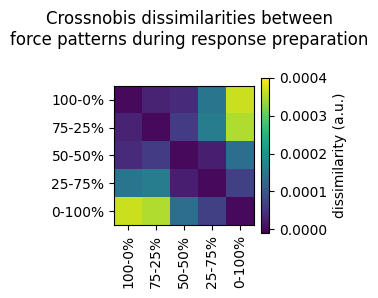

In [8]:
from vis import plot_dissimilarities

fig, ax = plt.subplots(figsize=(2, 3))

vmin, vmax = -.00001, .0004

G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.force.plan.npy'))
Df = pcm.G_to_dist(G)
fig, ax = plot_dissimilarities(fig, ax, None, Df, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=False, source='force')
cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=.05)
cbar.set_label('dissimilarity (a.u.)')

fig.suptitle('Crossnobis dissimilarities between\nforce patterns during response preparation')

plt.show()


M1
slope: -43.588288353206536, p = 0.306
intercept: 0.030060270986087805, p_intercept = 0.001
R2 = 0.087

S1
slope: -32.47334186924567, p = 0.453
intercept: 0.03990070014329524, p_intercept = 0.000
R2 = 0.048


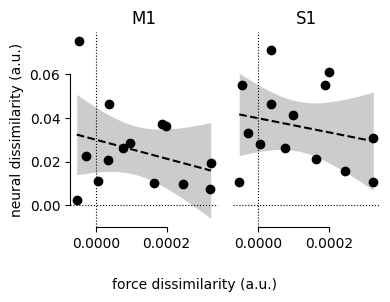

In [9]:
from vis import plot_correlation

rois_tmp = ['M1', 'S1']

fig, axs = plt.subplots(1, len(rois_tmp), sharex=True, sharey=True, figsize=(4, 3))

x = Df.mean(axis=(1, 2))

for r, roi in enumerate(rois_tmp):
    print(f'\n{roi}')
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D = np.array([pcm.G_to_dist(Gg) for Gg in G])
    y = D.mean(axis=(1, 2))
    fig, axs =  plot_correlation(fig, axs, r, x, y, alternative_slope='two-sided', alternative_intercept='two-sided')
    axs[r].set_title(roi)

for ax in axs:
    yticks = ax.get_yticks()
    xticks = ax.get_xticks()
    ax.spines['left'].set_bounds(yticks[1], yticks[-2])
    ax.spines['bottom'].set_bounds(xticks[1], xticks[-2])

axs[0].set_ylabel('neural dissimilarity (a.u.)', fontsize=10)
axs[1].tick_params('y', left=False)
fig.supxlabel('force dissimilarity (a.u.)', fontsize=10)

fig.tight_layout()

plt.show()

In [10]:
Data = np.random.rand(100, 1000)
part_vec = np.repeat(np.arange(10), 10)
cond_vec = np.tile(np.arange(10), 10)
obs_des = {'cond_vec': cond_vec, 'part_vec': part_vec}
G_obs, _ = pcm.est_G_crossval(Data, cond_vec, part_vec, X=pcm.indicator(part_vec))
D = pcm.G_to_dist(G_obs)

D.mean()

np.float64(-0.0001272827437406513)